📊 **Statistics Learning Journey -> Day 3**

***Companies often struggle to identify which customers truly drive revenue.
Not all customers contribute equally,a small percentage often generates a large share of revenue***

##📖 This Notebook focuses on :

- Identify high-value customers
- Understand spending distribution
- Detect outliers (VIP or abnormal behavior)
- Help business make targeted decisions

##📌 Problem Statement

* In modern businesses, not all customers contribute equally to revenue. A small segment of customers often drives a disproportionately large share of total spending, while others remain low-value or inconsistent in their purchasing behavior.

* This project aims to analyze customer data using statistical techniques and exploratory data analysis (EDA) to identify patterns in spending behavior. By leveraging concepts such as central tendency, dispersion, quantiles, percentiles, and boxplots, the goal is to segment customers based on their value, detect high-value (VIP) customers and outliers, and understand variability across different customer groups.

* The insights derived from this analysis will help businesses make data-driven decisions for targeted marketing, customer retention, and revenue optimization.

⚡ ***Import Libraries***

In [55]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

⚡ ***Create Dataset***

In [56]:

data = {
    "Customer_ID": list(range(1, 21)),
    "Age": [23,45,34,25,40,29,31,22,35,28,50,27,48,33,26,41,38,24,47,30],
    "Gender": ["Female","Male","Female","Male","Female","Male","Female","Female","Male","Male",
               "Female","Female","Male","Female","Male","Female","Male","Female","Male","Female"],
    "Annual_Income": [15000,54000,32000,27000,65000,48000,52000,19000,75000,41000,
                      80000,30000,60000,58000,36000,72000,68000,23000,90000,54000],
    "Spending_Score": [39,81,6,77,40,76,6,94,3,72,14,99,15,77,35,66,4,73,5,92],
    "Purchase_Amount": [120,450,50,400,200,380,60,500,40,350,90,520,100,420,180,300,70,360,80,480]
}

df = pd.DataFrame(data)

df

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Amount
0,1,23,Female,15000,39,120
1,2,45,Male,54000,81,450
2,3,34,Female,32000,6,50
3,4,25,Male,27000,77,400
4,5,40,Female,65000,40,200
5,6,29,Male,48000,76,380
6,7,31,Female,52000,6,60
7,8,22,Female,19000,94,500
8,9,35,Male,75000,3,40
9,10,28,Male,41000,72,350


⚡ ***Data Check***

In [57]:
# Check 7 rows using head()

df.head(7)

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Amount
0,1,23,Female,15000,39,120
1,2,45,Male,54000,81,450
2,3,34,Female,32000,6,50
3,4,25,Male,27000,77,400
4,5,40,Female,65000,40,200
5,6,29,Male,48000,76,380
6,7,31,Female,52000,6,60


Displays the first 7 rows of the dataset, providing a quick preview of the data structure and key features such as Customer_ID, Age, Gender, Annual_Income, Spending_Score, and Purchase_Amount. This helps in understanding how the data is organized.

In [58]:
# Check Statistical summary using describe()

df.describe()

,Customer_ID,Age,Annual_Income,Spending_Score,Purchase_Amount
count,20.00000,20.000000,20.000000,20.000000,20.00000
mean,10.50000,33.800000,49950.000000,48.700000,257.50000
std,5.91608,8.853189,21529.600187,35.258594,173.80797
min,1.00000,22.000000,15000.000000,3.000000,40.00000
25%,5.75000,26.750000,31500.000000,12.000000,87.50000
50%,10.50000,32.000000,53000.000000,53.000000,250.00000
75%,15.25000,40.250000,65750.000000,77.000000,405.00000
max,20.00000,50.000000,90000.000000,99.000000,520.00000


Generates statistical summaries for numerical columns, including: count , mean , std , min , max etc.

In [59]:
# Check dataset informations using info()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Customer_ID      20 non-null     int64 
 1   Age              20 non-null     int64 
 2   Gender           20 non-null     object
 3   Annual_Income    20 non-null     int64 
 4   Spending_Score   20 non-null     int64 
 5   Purchase_Amount  20 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 1.1+ KB


 Provides a concise summary of the dataset, including: Columns , dtype , Non-null count, memory usage of dataset.

In [60]:
# Check last 3 rows using tail()

df.tail()

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Amount
15,16,41,Female,72000,66,300
16,17,38,Male,68000,4,70
17,18,24,Female,23000,73,360
18,19,47,Male,90000,5,80
19,20,30,Female,54000,92,480


Returns the last 5 rows of the dataset, allowing verification of data consistency and ensuring there are no unexpected issues at the end of the dataset.

In [61]:
# Check missing values

df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
Annual_Income,0
Spending_Score,0
Purchase_Amount,0



The dataset contains no missing values across any column.

##🔍 Key Takeaway

These initial checks ensure that the dataset is well-structured, clean, and ready for further exploratory data analysis and statistical insights.

⚡ ***Statistical Summary***

In [62]:
df[["Annual_Income", "Spending_Score"]].agg(["mean", "median", "std"])

,Annual_Income,Spending_Score
mean,49950.000000,48.700000
median,53000.000000,53.000000
std,21529.600187,35.258594


- The comparison between mean and median for spending score indicates a slight skew in the distribution. The presence of higher mean values suggests that a few high-spending customers are influencing the average.

- Additionally, the standard deviation highlights variability in customer spending behavior, indicating that customers do not spend uniformly and require segmentation for better analysis.

⚡ ***Univariate Analysis***

**Univariate analysis is the simplest form of data analysis where only one variable (column) is analyzed at a time to understand its properties and distribution**

🎯 Purpose:

* To understand data distribution
* It Detects patterns or outliers
* Summarize a single feature before deeper analysis

🚀***A. Histogram***

📈**Spending Score Distribution**

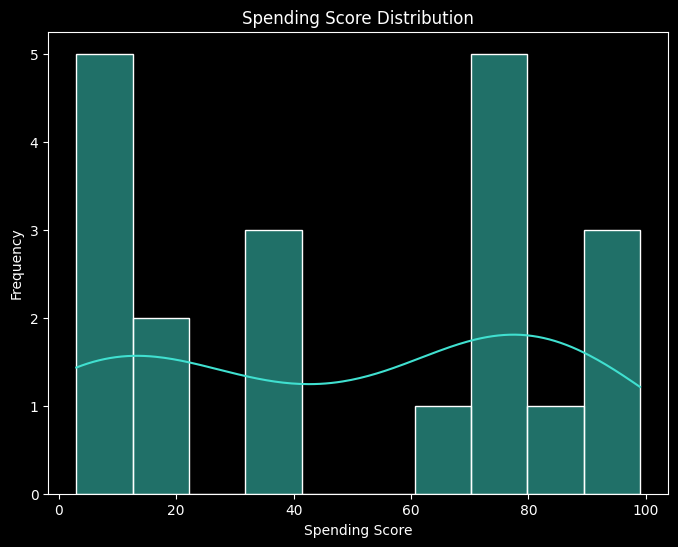

In [63]:

plt.figure(figsize=(8, 6))


plt.style.use("dark_background")

sns.histplot(df["Spending_Score"] ,
             bins = 10,
             kde = True,
             color = "turquoise")

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Frequency")

plt.savefig("histogram03.png", dpi=300, bbox_inches='tight')

plt.show()

***The distribution of spending scores shows that most customers fall within a mid-range, indicating moderate spending behavior. The distribution appears slightly right-skewed, suggesting the presence of a few high-spending customers.***

🚀***B. Countplot***

📈**Gender Count Plot**

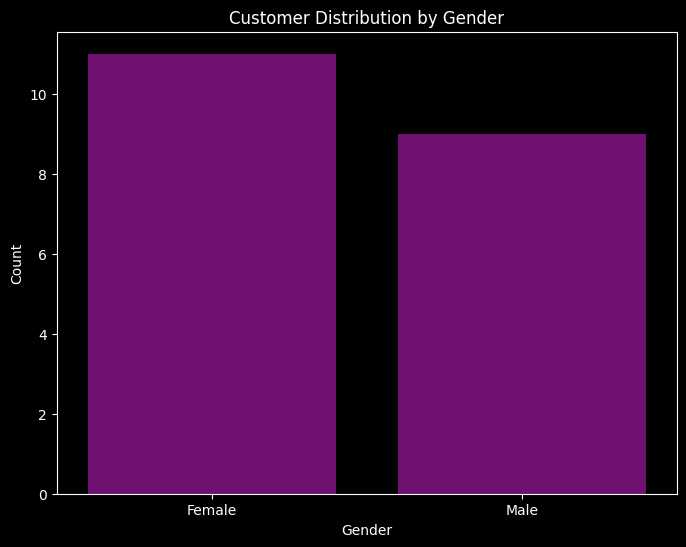

In [64]:

plt.figure(figsize=(8, 6))


plt.style.use("dark_background")

sns.countplot(x="Gender", data=df,
              color = "purple")
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig("countplot03.png", dpi=300, bbox_inches='tight')

plt.show()

***The bar plot shows the distribution of customers across gender categories. The dataset appears relatively balanced, with no significant dominance of one gender over the other, ensuring fair representation for analysis***

⚡ ***Bivariate Analysis***

**Bivariate analysis is the process of analyzing two variables together to understand the relationship, dependency, or pattern between them.**

🚀***A. Scatterplot***

📈**Income vs Spending**

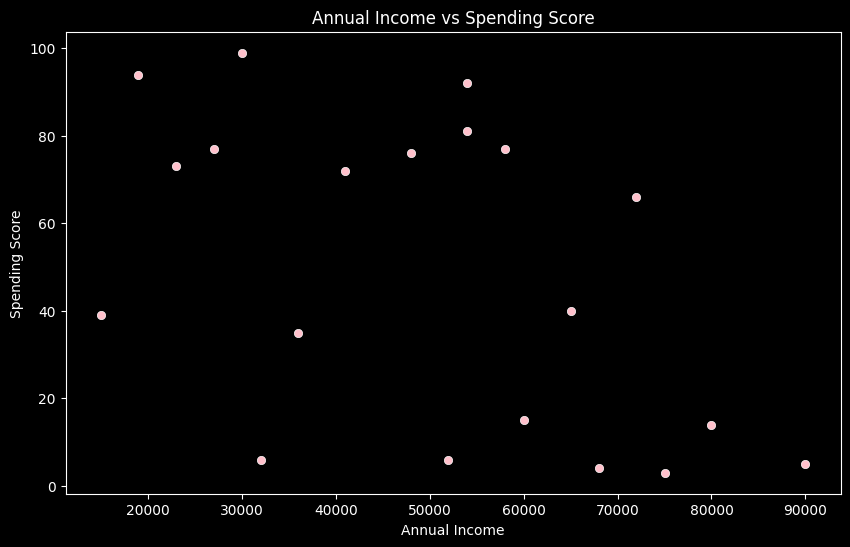

In [65]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x="Annual_Income",y="Spending_Score",
                data = df,
                color = "pink")

s=80

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.savefig("scatterplot03.png", dpi=300, bbox_inches='tight')

plt.show()

***The scatterplot shows the relationship between annual income and spending score. There is no strong linear correlation observed, indicating that higher income does not necessarily translate to higher spending. This suggests that customer behavior is influenced by factors beyond income alone.***

🚀***B. Side-by-Side Boxplot***

📈**Gender vs Spending**

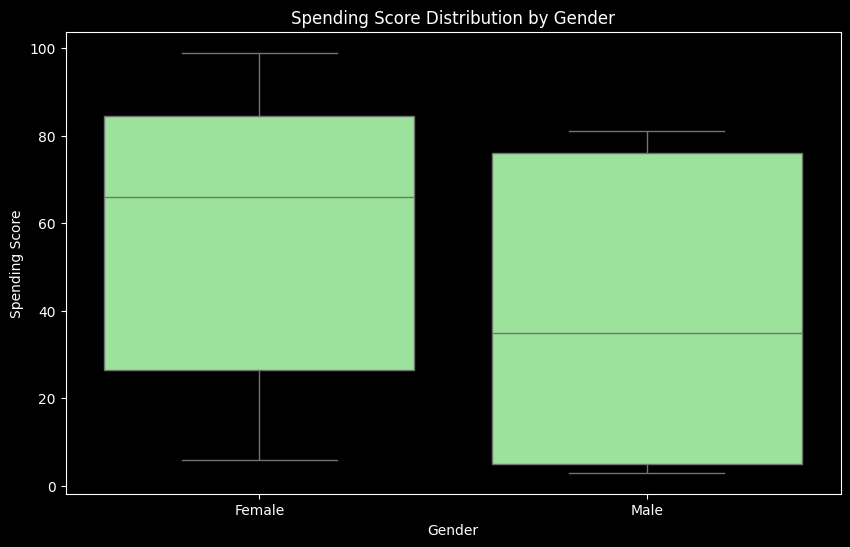

In [66]:

plt.figure(figsize=(10, 6))

sns.boxplot(x="Gender", y="Spending_Score", data=df,
            color = "lightgreen")

plt.title("Spending Score Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Spending Score")

plt.savefig("boxplot03.png", dpi=300, bbox_inches='tight')
plt.show()

***The comparison of spending scores across gender groups reveals differences in median and spread. One group shows slightly higher median spending, indicating potential variation in purchasing behavior across customer segments.***

##**While bivariate analysis provides insights into relationships between variables, it does not fully capture customer value distribution. Therefore, quantile-based segmentation is used to identify high-value and low-value customer groups.**

⚡***Quantile-Based Customer Segmentation***

**Quantiles are values that divide a dataset into equal-sized intervals based on the distribution of data.**

**For example, quartiles are a type of quantile that divide the data into four equal parts (25%, 50%, 75%). Quantiles provide a flexible way to understand how data is distributed across different ranges and are widely used for segmentation and analysis.**

💻**Calculate Quantiles**

In [67]:

quantile = df["Spending_Score"].quantile([0.25,0.5,0.75])
quantile

,Spending_Score
0.25,12.0
0.50,53.0
0.75,77.0


💻**Creating Customer Segments**

In [68]:
def segment_customer(score):
  if score <= quantile.loc[0.25]:
    return "Low value"
  elif score <= quantile[0.5]:
    return "Medium value"
  else:
    return "High value"

df["Customer_Segment"] = df["Spending_Score"].apply(segment_customer)

💻 **Counting Customers in Each Segment**

In [69]:
df["Customer_Segment"].value_counts()

,count
Customer_Segment,
High value,10
Medium value,5
Low value,5


In [70]:
df["Spending_Score"].value_counts()

,count
Spending_Score,
77,2
6,2
81,1
39,1
40,1
76,1
94,1
3,1
72,1


***Customers are divided into three segments based on spending behavior: low, medium, and high value. The majority of customers fall within the medium segment, while a smaller proportion belongs to the high-value category.***

💻***Visualize Segments***

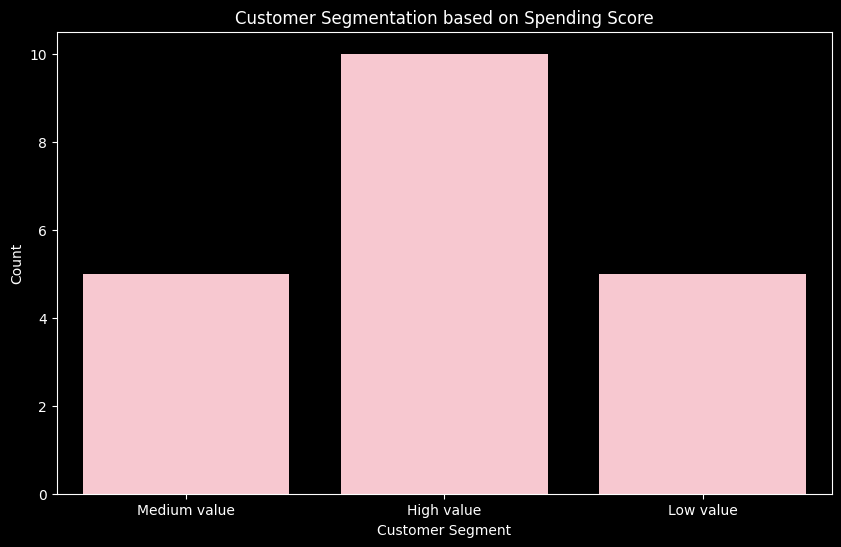

In [71]:

plt.figure(figsize=(10, 6))

sns.countplot(x="Customer_Segment",
              data=df,
              color="pink")

plt.title("Customer Segmentation based on Spending Score")
plt.xlabel("Customer Segment")
plt.ylabel("Count")

plt.savefig("countplot.1.03.png", dpi=300, bbox_inches='tight')
plt.show()

***The visualization highlights that high-value customers form a smaller group compared to others, yet they are likely to contribute significantly to overall revenue.***

💻***Compare Segments***

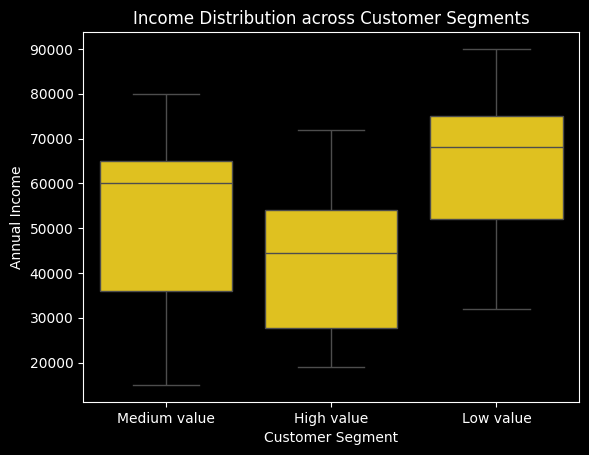

In [72]:
sns.boxplot(x="Customer_Segment",
            y="Annual_Income",
            data=df,
            color = "gold")


plt.title("Income Distribution across Customer Segments")

plt.xlabel("Customer Segment")
plt.ylabel("Annual Income")

plt.savefig("boxplot.1.03.png", dpi=300, bbox_inches='tight')
plt.show()

***High-value customers tend to show varied income levels, suggesting that spending behavior is not solely dependent on income. This indicates the importance of behavioral segmentation over purely demographic factors.***

⚡ ***Percentile Analysis***

**Percentiles indicate the value below which a given percentage of observations fall.**






💻 **Calculate Percentiles**

In [73]:
p25 = df["Spending_Score"].quantile(0.25)
p50 = df["Spending_Score"].quantile(0.50)
p75 = df["Spending_Score"].quantile(0.75)

p90 = df["Spending_Score"].quantile(0.90)
p95 = df["Spending_Score"].quantile(0.95)

💻 **Print Values**

In [74]:
print("25th Percentile:", p25)
print("50th Percentile (Median):", p50)
print("75th Percentile:", p75)
print("90th Percentile:", p90)
print("95th Percentile:", p95)

25th Percentile: 12.0
50th Percentile (Median): 53.0
75th Percentile: 77.0
90th Percentile: 92.2
95th Percentile: 94.25


💻**Identify Top Customers**

In [75]:
top_10_percent = df[df["Spending_Score"] >= p90]
top_5_percent = df[df["Spending_Score"] >= p95]

top_10_percent

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Amount,Customer_Segment
7,8,22,Female,19000,94,500,High value
11,12,27,Female,30000,99,520,High value


In [76]:
top_5_percent

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Amount,Customer_Segment
11,12,27,Female,30000,99,520,High value


***Customers above the 90th and 95th percentiles represent the highest spenders in the dataset. These customers contribute disproportionately to revenue and can be considered premium or VIP segments.***

💻 **Adding Percentile Column**

In [77]:
df["Spending_Percentile"] = df["Spending_Score"].rank(pct=True) * 100
df["Spending_Percentile"]

,Spending_Percentile
0,45.0
1,85.0
2,22.5
3,77.5
4,50.0
5,70.0
6,22.5
7,95.0
8,5.0
9,60.0


***Assigning percentile ranks to each customer allows for a more granular understanding of their relative position within the dataset, enabling precise targeting and segmentation strategies.***

💻**Visualization**

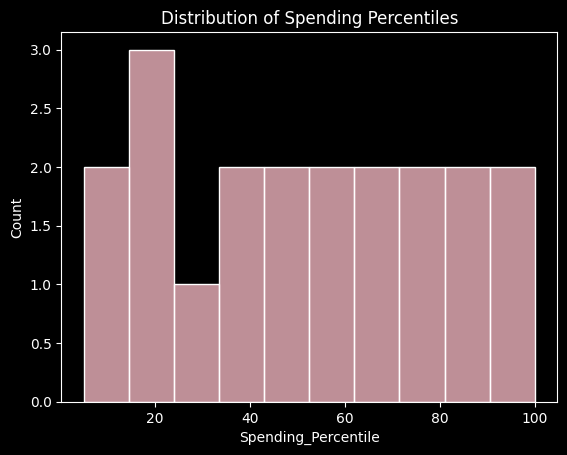

In [78]:
sns.histplot(df["Spending_Percentile"],
             bins=10,
             color="pink")
plt.title("Distribution of Spending Percentiles")

plt.savefig("histogram.1.03.png", dpi=300, bbox_inches='tight')
plt.show()

## 🧠 Insights

- **The analysis of customer spending behavior using both quantiles and percentiles reveals that customer value is highly unevenly distributed.**

- **Quantile-based segmentation shows that the majority of customers fall within the medium-value segment, while a smaller proportion belongs to the high-value category. This indicates that not all customers contribute equally to overall business performance.**

- **Further, percentile analysis provides deeper granularity by identifying the top-performing customers. Customers above the 90th and 95th percentiles represent the highest spenders in the dataset and contribute disproportionately to total revenue. These customers can be considered premium or VIP segments.**

- **The presence of a gap between upper quantiles and extreme percentile values also highlights the existence of outliers, reinforcing that a small group of customers drives a significant portion of spending.**

- **Overall, this combined approach demonstrates that relying solely on averages can be misleading, and that quantile- and percentile-based segmentation is essential for accurately understanding customer value distribution**

⚡ ***Quartile Analysis***

**Quartiles divide a dataset into four equal parts based on the distribution of values.**

- **Q1 (First Quartile): 25% of the data lies below this value**
- **Q2 (Median): 50% of the data lies below this value**
- **Q3 (Third Quartile): 75% of the data lies below this value**

***Quartiles help in understanding the spread and distribution of data, especially the middle 50% (Interquartile Range).***

💻**Calculate Quartiles**

In [79]:
q1 = df["Spending_Score"].quantile(0.25)
q2 = df["Spending_Score"].quantile(0.50)  # Median
q3 = df["Spending_Score"].quantile(0.75)

print("Q1:", q1)
print("Median (Q2):", q2)
print("Q3:", q3)

Q1: 12.0
Median (Q2): 53.0
Q3: 77.0


***The first quartile (Q1) represents the lower 25% of customers with relatively low spending scores, while the third quartile (Q3) represents the top 25% of customers with higher spending behavior. The median (Q2) indicates the central tendency of the dataset.***

💻**Calculate IQR**

In [80]:
iqr = q3 - q1
print("IQR:", iqr)

IQR: 65.0


***The interquartile range (IQR) measures the spread of the middle 50% of the data. A larger IQR indicates higher variability in customer spending, suggesting diverse purchasing behavior among customers.***

💻**Detect Outliers**

In [81]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df["Spending_Score"] < lower_bound) |
              (df["Spending_Score"] > upper_bound)]

outliers

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Amount,Customer_Segment,Spending_Percentile


💻 **Visualization**

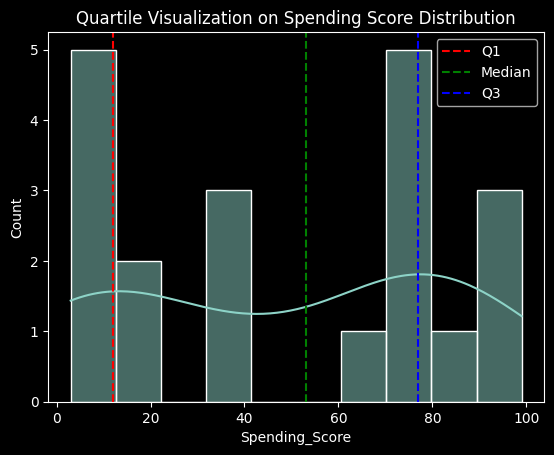

In [82]:
sns.histplot(df["Spending_Score"], bins=10, kde=True)

plt.axvline(df["Spending_Score"].quantile(0.25), color='red', linestyle='--', label='Q1')
plt.axvline(df["Spending_Score"].quantile(0.50), color='green', linestyle='--', label='Median')
plt.axvline(df["Spending_Score"].quantile(0.75), color='blue', linestyle='--', label='Q3')

plt.title("Quartile Visualization on Spending Score Distribution")
plt.legend()

plt.savefig("histogram.2.03.png", dpi=300, bbox_inches='tight')
plt.show()

***Values lying beyond the lower and upper bounds are considered outliers. These extreme values represent unusual customer behavior, which may indicate high-value customers (VIPs) or anomalies that require further investigation***

***The quartile lines divide the distribution into four equal parts, providing a clear visual understanding of how customer spending is spread.***

⚡ ***5-Number Summary***

In [83]:
five_num = df["Spending_Score"].describe()[["min", "25%", "50%", "75%", "max"]]
five_num

,Spending_Score
min,3.0
25%,12.0
50%,53.0
75%,77.0
max,99.0


💻**Visualization**

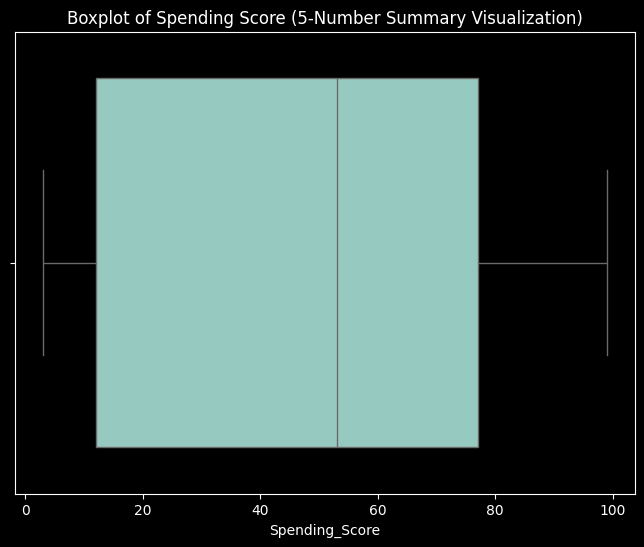

In [84]:

plt.figure(figsize=(8, 6))
sns.boxplot(x=df["Spending_Score"])

plt.title("Boxplot of Spending Score (5-Number Summary Visualization)")

plt.savefig("boxplot.2.03.png", dpi=300, bbox_inches='tight')
plt.show()

## 🧠 Insights

- **The 5-number summary provides a concise statistical overview of the spending score distribution, including the minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum values.**

- **The interquartile range (Q1 to Q3) captures the middle 50% of customers, indicating where most spending behavior is concentrated. The difference between the maximum value and the upper quartile suggests the presence of high-spending customers, reinforcing the existence of premium segments within the dataset.**

- **This summary complements the quantile and percentile analysis by clearly highlighting the spread and skewness of customer spending behavior.**

- **The boxplot visually represents the 5-number summary, including the minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum values.**

##📊 Key Findings

- **Customer spending is unevenly distributed, with a small segment contributing disproportionately to total spending.**
- **High-value customers identified through top percentiles (90th–95th) act as key revenue drivers.**
- **Majority of customers fall within the interquartile range (Q1–Q3), indicating moderate spending behavior.**
- **Presence of outliers highlights extreme spending patterns, representing potential VIP customers or anomalies.**
- **Weak correlation between annual income and spending score suggests that higher income does not necessarily lead to higher spending.**
- **Significant variability in spending behavior indicates the need for customer segmentation.**
- **Differences observed across customer groups (e.g., gender) suggest variation in purchasing behavior.**

##🚀Overall Insight

* **The analysis reveals that customer value is highly skewed, with a small segment of customers contributing disproportionately to overall spending. While the majority of customers exhibit moderate and consistent behavior, a distinct group of high-value customers emerges through quantile and percentile analysis.**

* **Additionally, the weak relationship between income and spending highlights that customer behavior is not solely driven by financial capacity, but also by underlying preferences and engagement patterns. This emphasizes the importance of behavioral analysis over purely demographic assumptions**

##🎯 Final Conclusion

**By leveraging statistical techniques such as central tendency, dispersion, quantiles, percentiles, and the 5-number summary, this project demonstrates how data can be transformed into actionable insights.**

**The findings confirm that customer segmentation is essential for understanding value distribution, identifying high-impact customers, and enabling targeted decision-making. Rather than treating all customers equally, businesses must adopt a segmented and data-driven approach to maximize revenue and improve customer engagement.**

***In a data-driven environment, the ability to identify and act on high-value customer segments is not just an advantage , it is a necessity for sustainable growth and competitive success.***